# Titanic: Machine Learning from Disaster

**A data story exploring who survived the Titanic — and why.**

https://www.kaggle.com/competitions/titanic/overview

---

On April 15, 1912, the RMS Titanic sank after colliding with an iceberg. Of the 2,224 passengers and crew aboard, more than 1,500 died — making it one of the deadliest maritime disasters in history. The phrase "women and children first" became synonymous with the tragedy. But was survival really governed by chivalry — or by something else entirely?

In this notebook we investigate the Titanic passenger manifest to answer a central question:

> **Who lived, who died, and what determined the difference — gallantry or privilege?**

## Setup

In [57]:
import os
import re

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap

from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve,
)
from sklearn.model_selection import (
    RandomizedSearchCV, StratifiedKFold, cross_val_score,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn import set_config

set_config(transform_output='pandas')

SEED = 42
np.random.seed(SEED)

In [58]:
# ── Reusable matplotlib style ─────────────────────────────────────────────────
# Copy this cell into any notebook for a consistent, polished look.

COLORS = {
    'survived':   '#2ecc71',
    'perished':   '#e74c3c',
    'primary':    '#2c3e50',
    'secondary':  '#7f8c8d',
    'accent':     '#3498db',
    'background': '#fafafa',
    'grid':       '#ecf0f1',
}

PALETTE = [
    '#3498db', '#e74c3c', '#2ecc71', '#f39c12',
    '#9b59b6', '#1abc9c', '#e67e22', '#34495e',
]

SURV_COLORS = [COLORS['perished'], COLORS['survived']]

plt.rcParams.update({
    'figure.figsize':       (10, 6),
    'figure.dpi':           120,
    'figure.facecolor':     COLORS['background'],
    'axes.facecolor':       COLORS['background'],
    'axes.edgecolor':       COLORS['grid'],
    'axes.grid':            True,
    'axes.spines.top':      False,
    'axes.spines.right':    False,
    'grid.color':           COLORS['grid'],
    'grid.alpha':           0.7,
    'font.family':          'sans-serif',
    'font.size':            11,
    'axes.titlesize':       14,
    'axes.titleweight':     'bold',
    'axes.labelsize':       12,
})

In [59]:
# ── Reusable chart helpers ────────────────────────────────────────────────────

def bar_with_labels(ax, bars, fmt='{:.1%}', fontsize=9, offset=0.01):
    """Annotate each bar with its value."""
    for bar in bars:
        val = bar.get_height() if bar.get_height() != 0 else bar.get_width()
        if bar.get_width() > bar.get_height():  # horizontal bar
            ax.text(bar.get_width() + offset, bar.get_y() + bar.get_height() / 2,
                    fmt.format(val), va='center', fontsize=fontsize, color=COLORS['primary'])
        else:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + offset,
                    fmt.format(val), ha='center', fontsize=fontsize, color=COLORS['primary'])


def survival_rate_bar(ax, series, title, xlabel='Survival Rate'):
    """Horizontal bar chart of survival rates by category."""
    rates = series.sort_values()
    colors = [COLORS['accent']] * len(rates)
    bars = ax.barh(rates.index.astype(str), rates.values, color=colors, edgecolor='white', height=0.6)
    bar_with_labels(ax, bars, offset=0.015)
    ax.set_xlim(0, 1.12)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.invert_yaxis()


def styled_heatmap(ax, data, cmap='RdYlGn', fmt='.1%', title='', vmin=0, vmax=1):
    """Annotated heatmap with custom colormap."""
    im = ax.imshow(data.values, cmap=cmap, aspect='auto', vmin=vmin, vmax=vmax)
    ax.set_xticks(range(data.shape[1]))
    ax.set_xticklabels(data.columns, rotation=0)
    ax.set_yticks(range(data.shape[0]))
    ax.set_yticklabels(data.index)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val = data.iloc[i, j]
            color = 'white' if val < 0.35 or val > 0.75 else 'black'
            ax.text(j, i, format(val, fmt), ha='center', va='center', color=color, fontsize=10)
    ax.set_title(title)
    return im


def add_subtitle(ax, text, y=-0.12):
    """Add a takeaway subtitle below the axes."""
    ax.text(0.5, y, text, transform=ax.transAxes, ha='center', va='top',
            fontsize=10, fontstyle='italic', color=COLORS['secondary'])

In [89]:
# ── Data loading ──────────────────────────────────────────────────────────────

def kaggle_dataset(url):
    dataset_path = kagglehub.competition_download(url)
    train_df = pd.read_csv(os.path.join(dataset_path, 'train.csv'))
    test_df = pd.read_csv(os.path.join(dataset_path, 'test.csv'))
    return train_df, test_df


def submit_to_kaggle(model, X, y, test_data, file_name, id_col, target_col):
    kaggle_model = model.fit(X, y)
    kaggle_predictions = kaggle_model.predict(test_data)
    kaggle_submission_df = pd.DataFrame({
        id_col: test_data[id_col],
        target_col: kaggle_predictions,
    })
    kaggle_submission_df.to_csv(file_name, index=False, header=True)


train, test = kaggle_dataset('titanic')
print(f'Train: {train.shape}  |  Test: {test.shape}')
train

Train: (891, 12)  |  Test: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


---

## 1. The Big Picture

Before diving into the details, let's see the headline number.

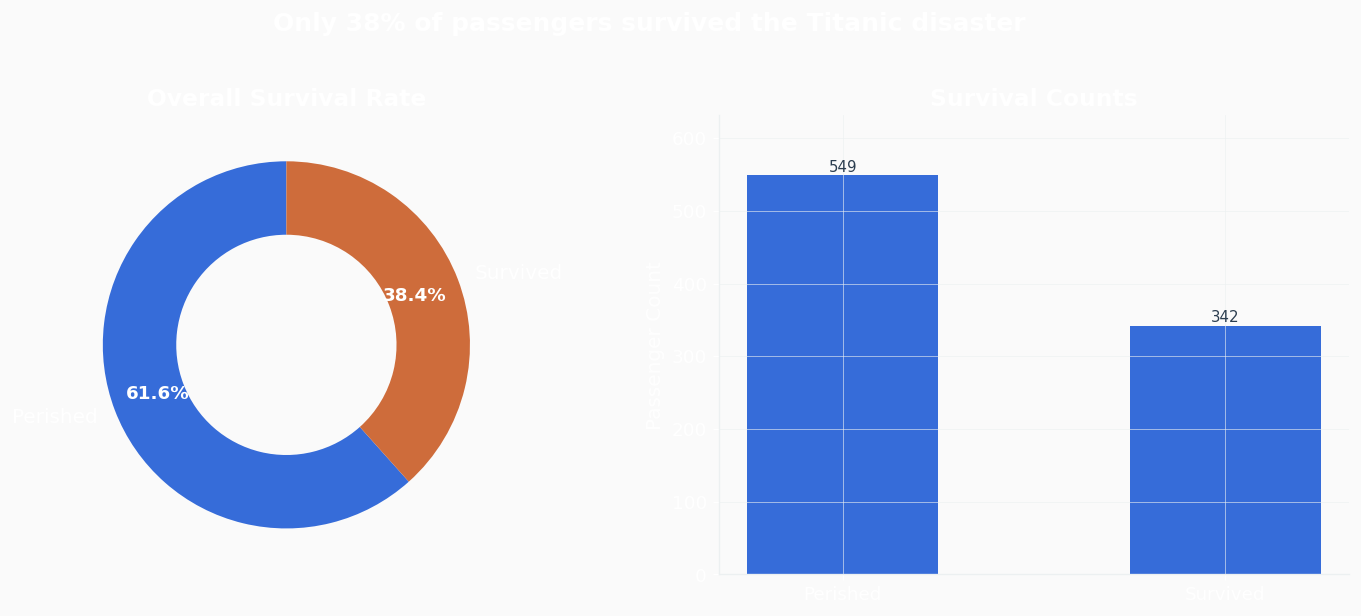

In [92]:
survived_counts = train['Survived'].value_counts().sort_index()
labels = ['Perished', 'Survived']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Donut chart
wedges, texts, autotexts = ax1.pie(
    survived_counts, labels=labels, colors=SURV_COLORS, autopct='%1.1f%%',
    startangle=90, pctdistance=0.75, wedgeprops=dict(width=0.4),
    textprops={'fontsize': 12},
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight('bold')
ax1.set_title('Overall Survival Rate')

# Counts bar chart
bars = ax2.bar(labels, survived_counts.values, color=SURV_COLORS, width=0.5)
bar_with_labels(ax2, bars, fmt='{:.0f}', offset=5)
ax2.set_ylabel('Passenger Count')
ax2.set_title('Survival Counts')
ax2.set_ylim(0, survived_counts.max() * 1.15)

fig.suptitle('Only 38% of passengers survived the Titanic disaster',
             fontsize=15, fontweight='bold', y=1.02)
fig.tight_layout()
plt.show()

---

## 2. The Obvious Suspects — Univariate Survival Analysis

Let's test the most intuitive hypotheses one at a time.

### 2.1 Sex

**Hypothesis:** Women were far more likely to survive due to the "women and children first" protocol.

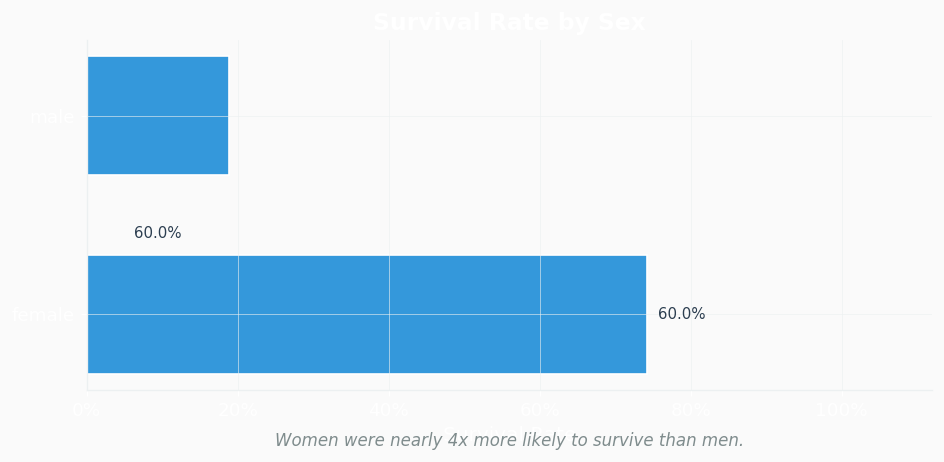

In [62]:
surv_by_sex = train.groupby('Sex')['Survived'].mean()

fig, ax = plt.subplots(figsize=(8, 4))
survival_rate_bar(ax, surv_by_sex, 'Survival Rate by Sex')
add_subtitle(ax, 'Women were nearly 4x more likely to survive than men.')
fig.tight_layout()
plt.show()

**Verdict:** Confirmed — sex is the strongest single predictor of survival.

### 2.2 Passenger Class

**Hypothesis:** Higher-class passengers had better access to lifeboats.

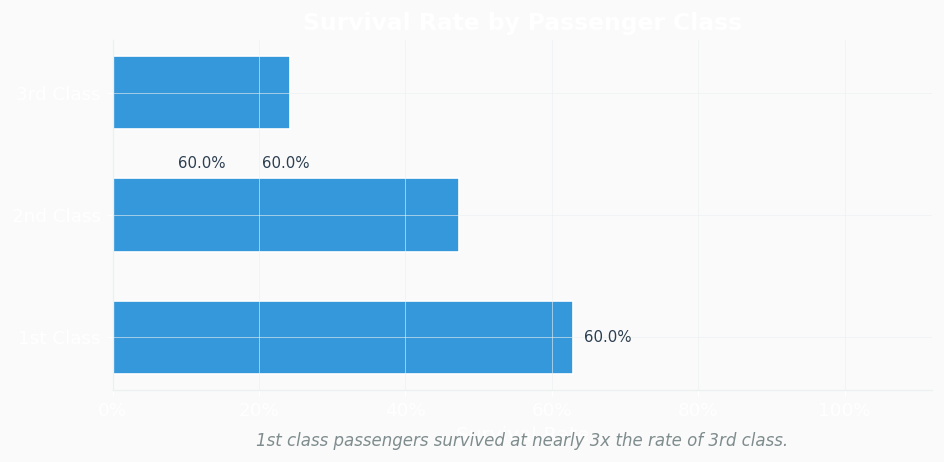

In [63]:
surv_by_class = train.groupby('Pclass')['Survived'].mean()
surv_by_class.index = ['1st Class', '2nd Class', '3rd Class']

fig, ax = plt.subplots(figsize=(8, 4))
survival_rate_bar(ax, surv_by_class, 'Survival Rate by Passenger Class')
add_subtitle(ax, '1st class passengers survived at nearly 3x the rate of 3rd class.')
fig.tight_layout()
plt.show()

**Verdict:** Confirmed — class was a powerful determinant. Privilege bought proximity to lifeboats.

### 2.3 Age

**Hypothesis:** Children had higher survival rates ("women and *children* first").

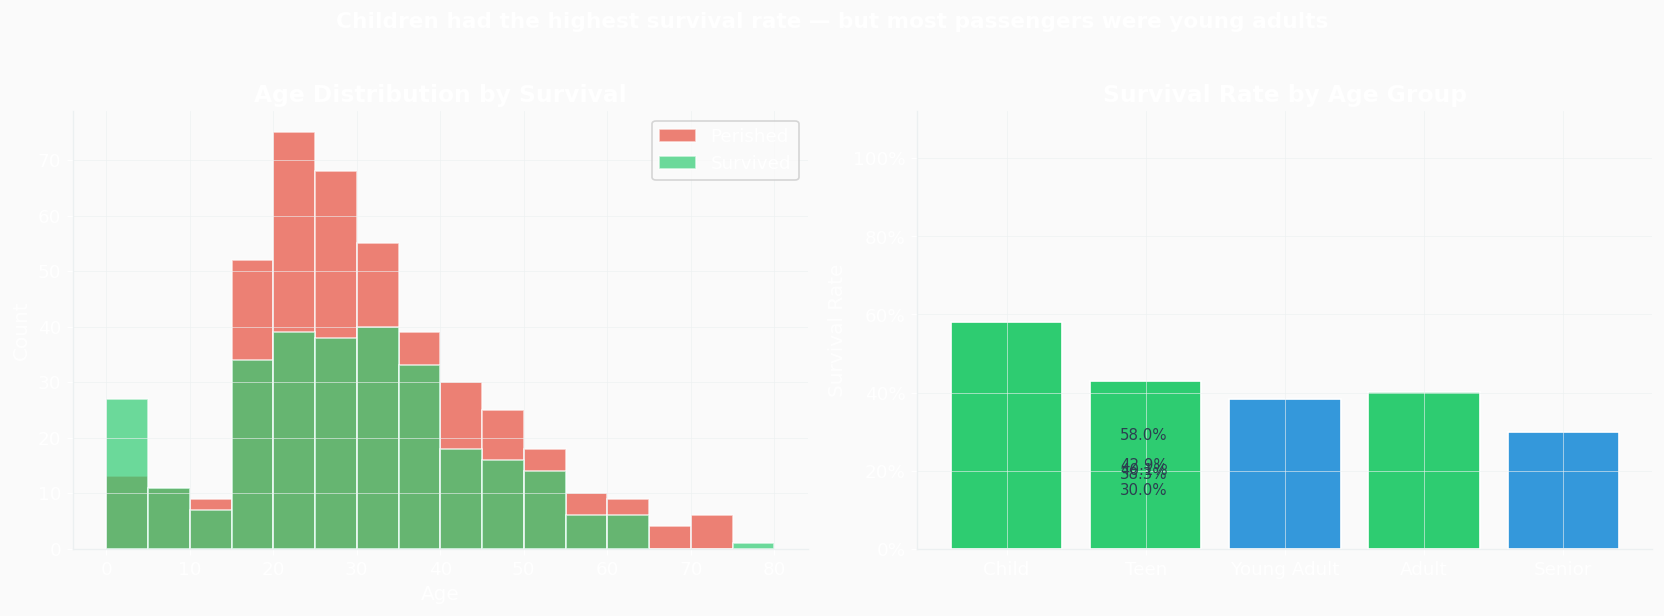

In [64]:
age_data = train.dropna(subset=['Age']).copy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Overlaid histograms
bins = np.arange(0, 85, 5)
ax1.hist(age_data.loc[age_data['Survived'] == 0, 'Age'], bins=bins, alpha=0.7,
         color=COLORS['perished'], label='Perished', edgecolor='white')
ax1.hist(age_data.loc[age_data['Survived'] == 1, 'Age'], bins=bins, alpha=0.7,
         color=COLORS['survived'], label='Survived', edgecolor='white')
ax1.set_xlabel('Age')
ax1.set_ylabel('Count')
ax1.set_title('Age Distribution by Survival')
ax1.legend()

# Survival rate by age group
age_data['AgeGroup'] = pd.cut(age_data['Age'], bins=[0, 12, 18, 35, 55, 80],
                               labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior'])
surv_by_age = age_data.groupby('AgeGroup', observed=True)['Survived'].mean()

bar_colors = [COLORS['survived'] if v > 0.4 else COLORS['accent'] for v in surv_by_age.values]
bars = ax2.bar(surv_by_age.index.astype(str), surv_by_age.values, color=bar_colors, edgecolor='white')
bar_with_labels(ax2, bars, offset=0.015)
ax2.set_ylim(0, 1.12)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax2.set_title('Survival Rate by Age Group')
ax2.set_ylabel('Survival Rate')

fig.suptitle('Children had the highest survival rate — but most passengers were young adults',
             fontsize=13, fontweight='bold', y=1.02)
fig.tight_layout()
plt.show()

**Verdict:** Children (under 12) had noticeably higher survival. But the bulk of passengers were 20-35 year olds where the split was much more even.

### 2.4 Port of Embarkation

**Hypothesis:** Passengers from Cherbourg had higher survival rates — but is this just a proxy for class?

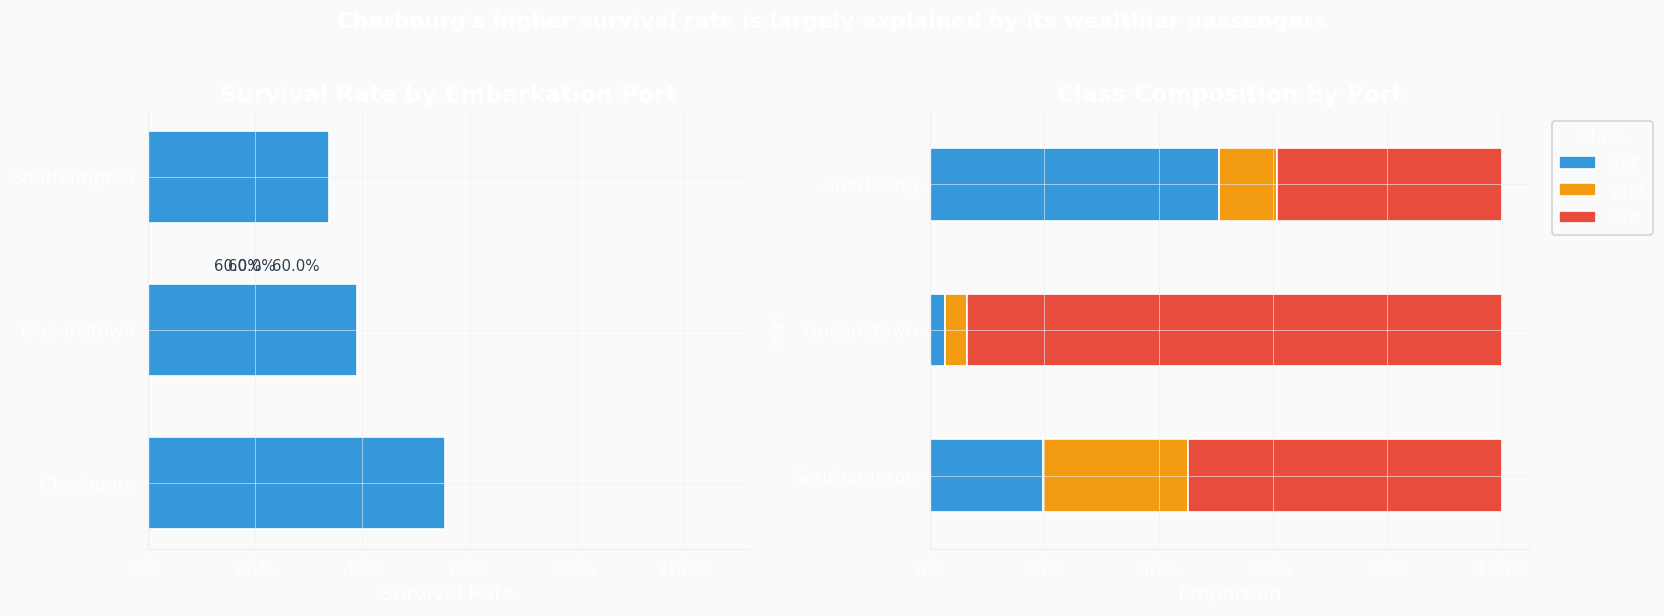

In [65]:
port_names = {'S': 'Southampton', 'C': 'Cherbourg', 'Q': 'Queenstown'}
embarked_data = train.dropna(subset=['Embarked']).copy()
embarked_data['Port'] = embarked_data['Embarked'].map(port_names)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Survival rate by port
surv_by_port = embarked_data.groupby('Port')['Survived'].mean()
survival_rate_bar(ax1, surv_by_port, 'Survival Rate by Embarkation Port')

# Class distribution by port (explains the survival difference)
class_by_port = embarked_data.groupby(['Port', 'Pclass']).size().unstack(fill_value=0)
class_by_port.columns = ['1st', '2nd', '3rd']
class_by_port_pct = class_by_port.div(class_by_port.sum(axis=1), axis=0)

class_by_port_pct.plot.barh(stacked=True, ax=ax2,
                             color=[PALETTE[0], PALETTE[3], PALETTE[1]], edgecolor='white')
ax2.set_title('Class Composition by Port')
ax2.set_xlabel('Proportion')
ax2.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax2.legend(title='Class', bbox_to_anchor=(1.02, 1), loc='upper left')
ax2.invert_yaxis()

fig.suptitle('Cherbourg\'s higher survival rate is largely explained by its wealthier passengers',
             fontsize=13, fontweight='bold', y=1.02)
fig.tight_layout()
plt.show()

**Verdict:** Cherbourg passengers survived at higher rates primarily because more of them were 1st class. Embarkation port is mostly a proxy for class.

---

## 3. Going Deeper — Interaction Effects

The univariate view tells part of the story. The real question is: **did the "women and children first" protocol apply equally across all classes?**

### 3.1 Sex x Class

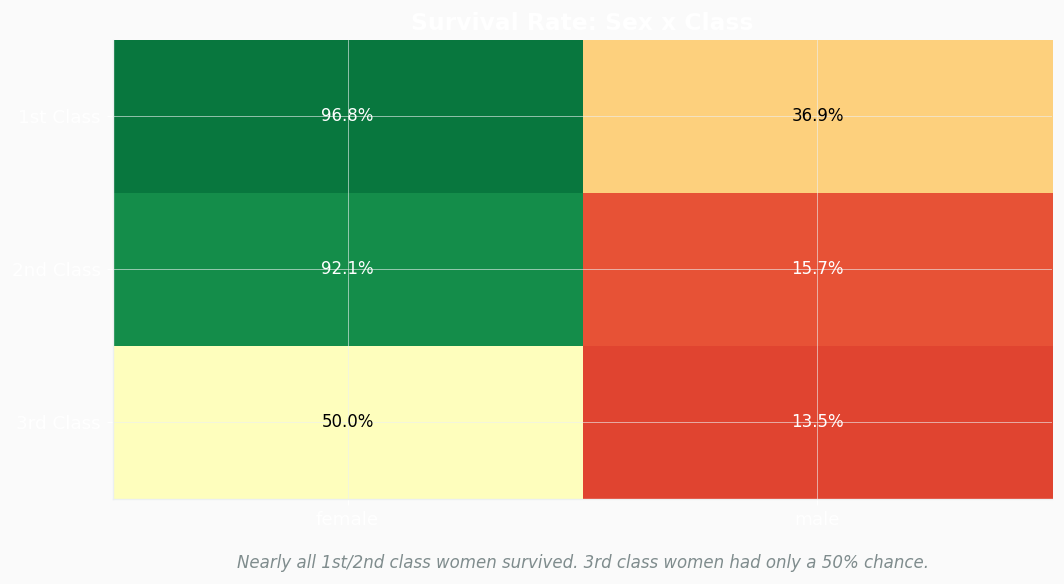

In [66]:
surv_sex_class = train.groupby(['Pclass', 'Sex'])['Survived'].mean().unstack()
surv_sex_class.index = ['1st Class', '2nd Class', '3rd Class']

fig, ax = plt.subplots(figsize=(9, 5))
styled_heatmap(ax, surv_sex_class, title='Survival Rate: Sex x Class')
add_subtitle(ax, 'Nearly all 1st/2nd class women survived. 3rd class women had only a 50% chance.')
fig.tight_layout()
plt.show()

This is the most revealing chart so far. "Women and children first" was enforced — but 3rd class women were far less protected than their 1st class counterparts. **Class filtered who even got to the lifeboats.**

### 3.2 Family Dynamics

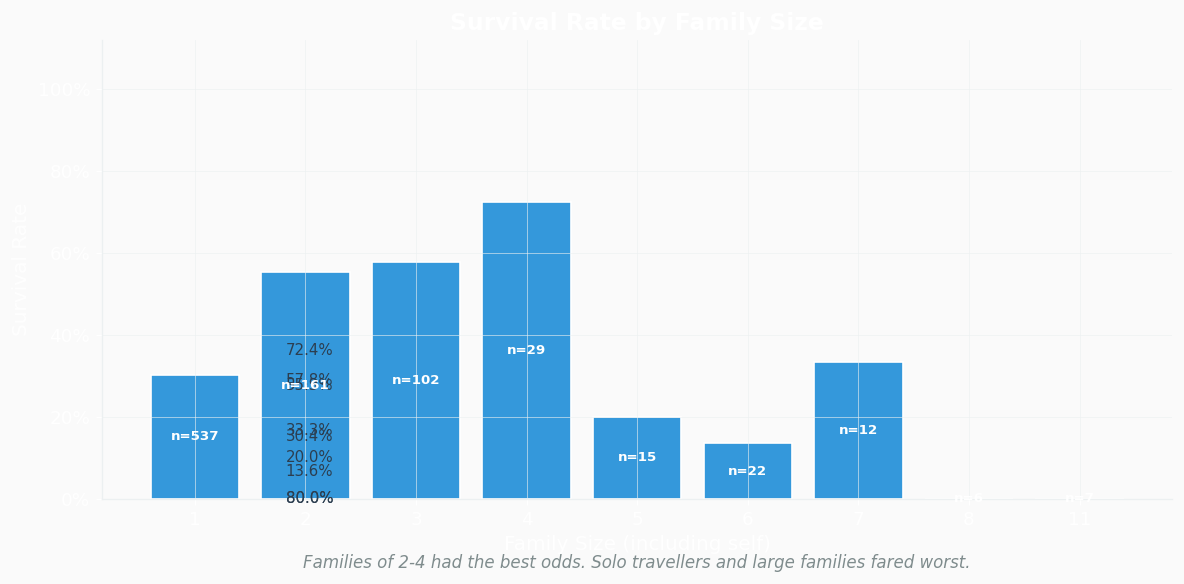

In [67]:
train['FamilySize'] = train['SibSp'] + train['Parch'] + 1
test['FamilySize'] = test['SibSp'] + test['Parch'] + 1

surv_by_fam = train.groupby('FamilySize')['Survived'].agg(['mean', 'count'])

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(surv_by_fam.index.astype(str), surv_by_fam['mean'],
              color=COLORS['accent'], edgecolor='white')
bar_with_labels(ax, bars, offset=0.02)

# Annotate counts on the bars
for i, (_, row) in enumerate(surv_by_fam.iterrows()):
    ax.text(i, row['mean'] / 2, f'n={int(row["count"])}',
            ha='center', va='center', fontsize=8, color='white', fontweight='bold')

ax.set_ylim(0, 1.12)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_xlabel('Family Size (including self)')
ax.set_ylabel('Survival Rate')
ax.set_title('Survival Rate by Family Size')
add_subtitle(ax, 'Families of 2-4 had the best odds. Solo travellers and large families fared worst.')
fig.tight_layout()
plt.show()

### 3.3 Were 3rd-Class Children Protected?

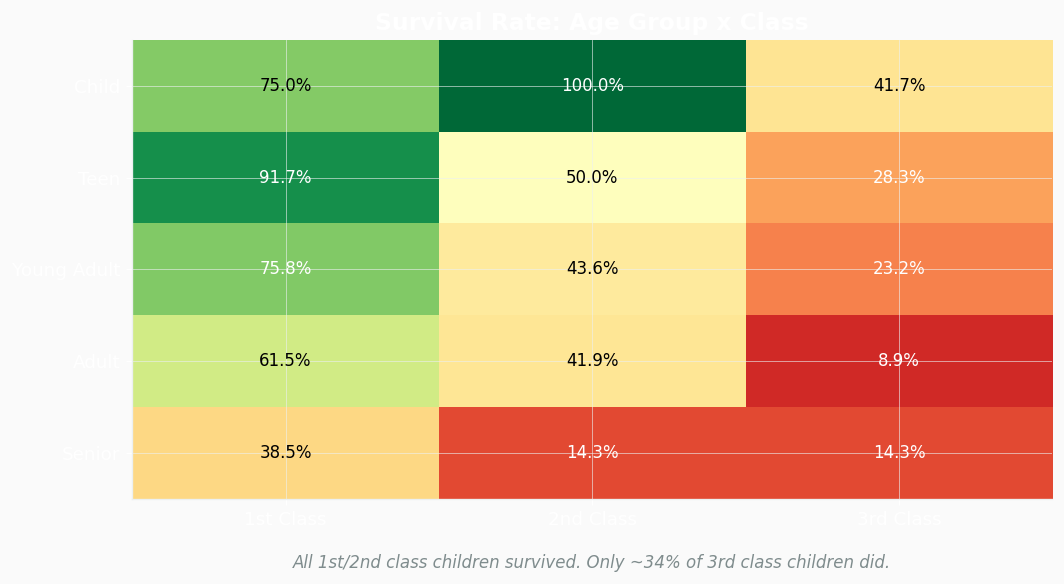

In [68]:
age_class = train.dropna(subset=['Age']).copy()
age_class['AgeGroup'] = pd.cut(age_class['Age'], bins=[0, 12, 18, 35, 55, 80],
                                labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior'])

surv_age_class = age_class.groupby(['AgeGroup', 'Pclass'], observed=True)['Survived'].mean().unstack()
surv_age_class.columns = ['1st Class', '2nd Class', '3rd Class']

fig, ax = plt.subplots(figsize=(9, 5))
styled_heatmap(ax, surv_age_class, title='Survival Rate: Age Group x Class')
add_subtitle(ax, 'All 1st/2nd class children survived. Only ~34% of 3rd class children did.')
fig.tight_layout()
plt.show()

---

## 4. Feature Engineering

Before modelling, let's extract more signal from the raw data.

### 4.1 Title Extraction

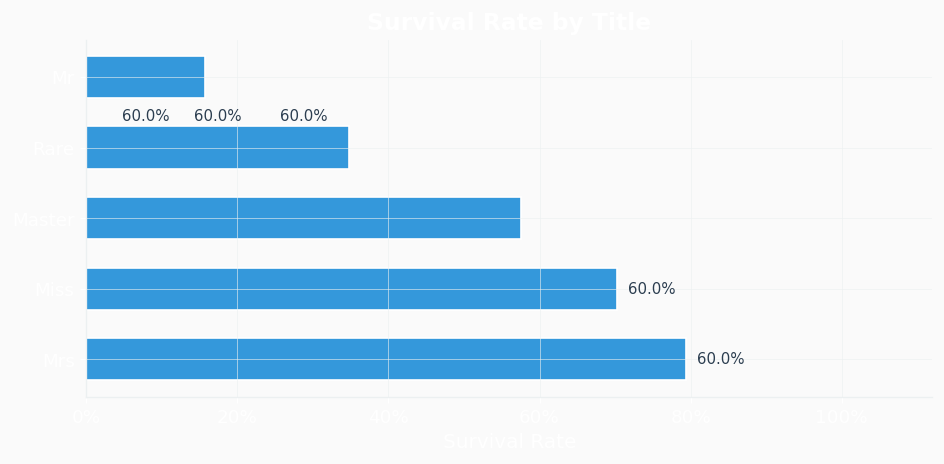

In [69]:
def extract_title(name):
    match = re.search(r'\b(\w+)\.', name)
    return match.group(1) if match else 'Unknown'


TITLE_MAP = {
    'Mr': 'Mr', 'Miss': 'Miss', 'Mrs': 'Mrs', 'Master': 'Master',
    'Mme': 'Mrs', 'Ms': 'Miss', 'Mlle': 'Miss',
    'Rev': 'Rare', 'Dr': 'Rare', 'Col': 'Rare', 'Major': 'Rare', 'Capt': 'Rare',
    'Sir': 'Rare', 'Lady': 'Rare', 'Don': 'Rare', 'Dona': 'Rare',
    'Countess': 'Rare', 'Jonkheer': 'Rare',
}

for df in [train, test]:
    df['Title'] = df['Name'].apply(extract_title).map(TITLE_MAP).fillna('Rare')

surv_by_title = train.groupby('Title')['Survived'].mean()

fig, ax = plt.subplots(figsize=(8, 4))
survival_rate_bar(ax, surv_by_title, 'Survival Rate by Title')
fig.tight_layout()
plt.show()

### 4.2 Family Features, Deck, Ticket Groups

In [70]:
for df in [train, test]:
    # IsAlone
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

    # HasCabin
    df['HasCabin'] = df['Cabin'].notna().astype(int)

    # Deck (first letter of Cabin where available)
    df['Deck'] = df['Cabin'].str[0].fillna('Unknown')

    # Ticket group size
    ticket_counts = df.groupby('Ticket')['Ticket'].transform('count')
    df['TicketGroupSize'] = ticket_counts

    # Fare per person
    df['FarePerPerson'] = df['Fare'] / df['TicketGroupSize']

print('Engineered features added.')
train[['Name', 'Title', 'FamilySize', 'IsAlone', 'HasCabin', 'Deck', 'TicketGroupSize', 'FarePerPerson']].head(10)

Engineered features added.


,Name,Title,FamilySize,IsAlone,HasCabin,Deck,TicketGroupSize,FarePerPerson
0,"Braund, Mr. Owen Harris",Mr,2,0,0,Unknown,1,7.25000
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs,2,0,1,C,1,71.28330
2,"Heikkinen, Miss. Laina",Miss,1,1,0,Unknown,1,7.92500
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs,2,0,1,C,2,26.55000
4,"Allen, Mr. William Henry",Mr,1,1,0,Unknown,1,8.05000
5,"Moran, Mr. James",Mr,1,1,0,Unknown,1,8.45830
6,"McCarthy, Mr. Timothy J",Mr,1,1,1,E,1,51.86250
7,"Palsson, Master. Gosta Leonard",Master,5,0,0,Unknown,4,5.26875
8,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",Mrs,3,0,0,Unknown,3,3.71110
9,"Nasser, Mrs. Nicholas (Adele Achem)",Mrs,2,0,0,Unknown,2,15.03540


### 4.3 Correlation with Survival

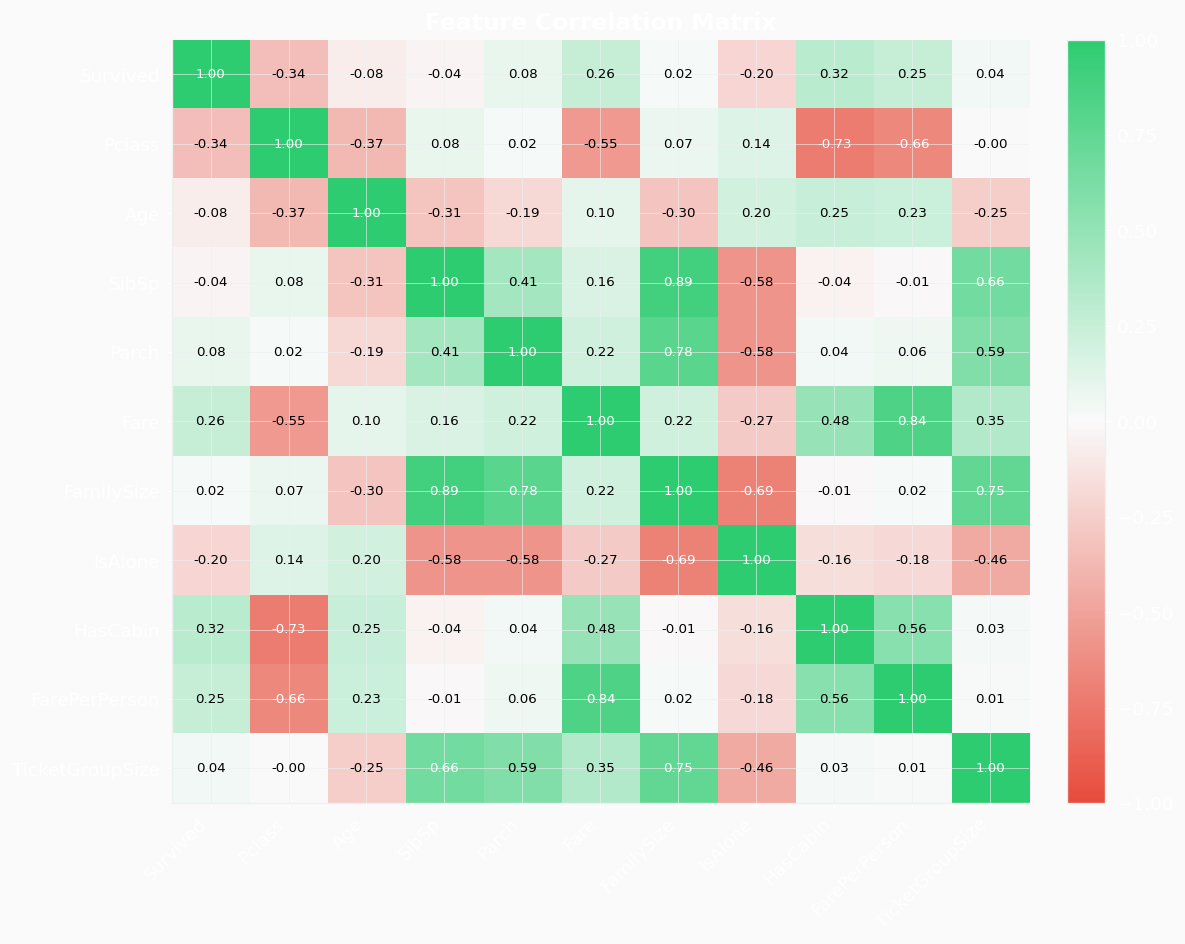

In [71]:
corr_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare',
             'FamilySize', 'IsAlone', 'HasCabin', 'FarePerPerson', 'TicketGroupSize']
corr = train[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
cmap = LinearSegmentedColormap.from_list('rg', [COLORS['perished'], '#fafafa', COLORS['survived']])
im = ax.imshow(corr.values, cmap=cmap, vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr)))
ax.set_yticklabels(corr.index)
for i in range(len(corr)):
    for j in range(len(corr)):
        val = corr.iloc[i, j]
        color = 'white' if abs(val) > 0.6 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8, color=color)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title('Feature Correlation Matrix')
fig.tight_layout()
plt.show()

---

## 5. Handling Missing Data

Transparency about missing data is essential for a trustworthy analysis.

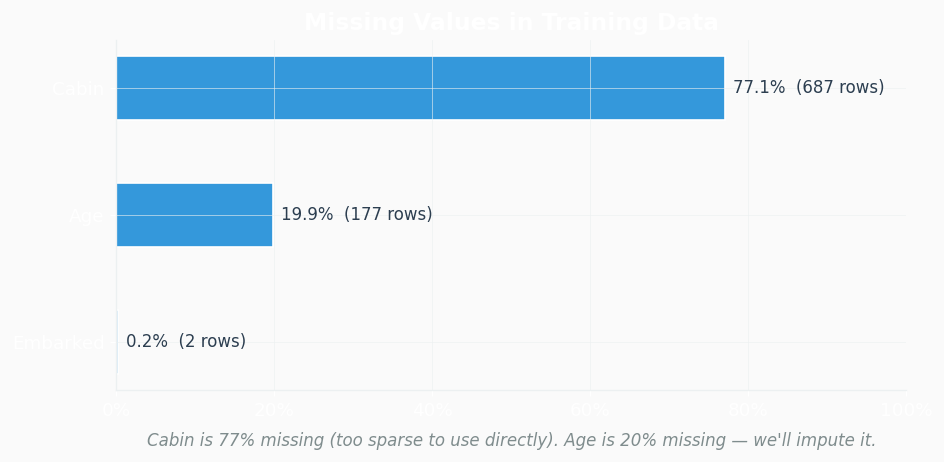

In [72]:
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=True)
missing_pct = missing / len(train)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(missing.index.astype(str), missing_pct.values, color=COLORS['accent'], edgecolor='white', height=0.5)
for bar, count in zip(bars, missing.values):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f'{bar.get_width():.1%}  ({count} rows)',
            va='center', fontsize=10, color=COLORS['primary'])
ax.set_xlim(0, 1.0)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_title('Missing Values in Training Data')
add_subtitle(ax, 'Cabin is 77% missing (too sparse to use directly). Age is 20% missing — we\'ll impute it.')
fig.tight_layout()
plt.show()

In [73]:
# Embarked: fill 2 missing values with mode
for df in [train, test]:
    df['Embarked'] = df['Embarked'].fillna('S')

# Fare: fill 1 missing value in test set with median
test['Fare'] = test['Fare'].fillna(train['Fare'].median())
test['FarePerPerson'] = test['Fare'] / test['TicketGroupSize']

print('Embarked and Fare missing values filled.')

Embarked and Fare missing values filled.


### Age Imputation

Age is 20% missing. We'll use KNN imputation (built into the preprocessing pipeline) which uses correlated features to estimate missing ages. Let's verify the distribution doesn't shift dramatically.

In [74]:
# Preview: median age by Title and Class (the basis for KNN imputation)
age_summary = train.groupby(['Title', 'Pclass'])['Age'].agg(['median', 'count']).round(1)
print('Median age by Title x Class (guides KNN imputation):')
age_summary

Median age by Title x Class (guides KNN imputation):


median  count
Title  Pclass               
Master 1          4.0      3
       2          1.0      9
       3          4.0     24
Miss   1         30.0     47
       2         24.0     33
       3         18.0     69
Mr     1         40.0     87
       2         31.0     82
       3         26.0    229
Mrs    1         40.0     35
       2         32.0     41
       3         31.0     33
Rare   1         48.5     14
       2         46.5      8

---

## 6. Experiments

Now we build a rigorous modelling pipeline and run systematic experiments.

In [75]:
# ── Feature definitions ───────────────────────────────────────────────────────

numeric_features = ['Pclass', 'SibSp', 'Parch', 'Fare', 'Age', 'FamilySize', 'FarePerPerson', 'TicketGroupSize']
categorical_features = ['Sex', 'Title', 'Embarked']
binary_features = ['IsAlone', 'HasCabin']

# ── Preprocessing ─────────────────────────────────────────────────────────────

numeric_transformer = Pipeline([
    ('scaler', StandardScaler()),
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
        ('bin', 'passthrough', binary_features),
    ],
    remainder='drop',
)

# ── Target / features ─────────────────────────────────────────────────────────

X = train.drop(columns=['Survived'])
y = train['Survived']

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print('Preprocessing pipeline defined.')
print(f'Features: {len(numeric_features)} numeric, {len(categorical_features)} categorical, {len(binary_features)} binary')

Preprocessing pipeline defined.
Features: 8 numeric, 3 categorical, 2 binary


### Experiment 1 — Baseline Models (no tuning)

In [76]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=SEED),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=SEED),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=SEED),
    'SVM':                 SVC(kernel='rbf', random_state=SEED),
    'KNN':                 KNeighborsClassifier(n_neighbors=5),
}

baseline_results = {}

for name, clf in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('imputer', KNNImputer()),
        ('classifier', clf),
    ])
    scores = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy')
    baseline_results[name] = {'mean': scores.mean(), 'std': scores.std(), 'scores': scores}
    print(f'{name:25s}  {scores.mean():.4f} +/- {scores.std():.4f}')

print('\nBaseline experiment complete.')

Logistic Regression        0.8272 +/- 0.0091
Random Forest              0.8103 +/- 0.0220
Gradient Boosting          0.8305 +/- 0.0210
SVM                        0.8339 +/- 0.0099
KNN                        0.8126 +/- 0.0134

Baseline experiment complete.


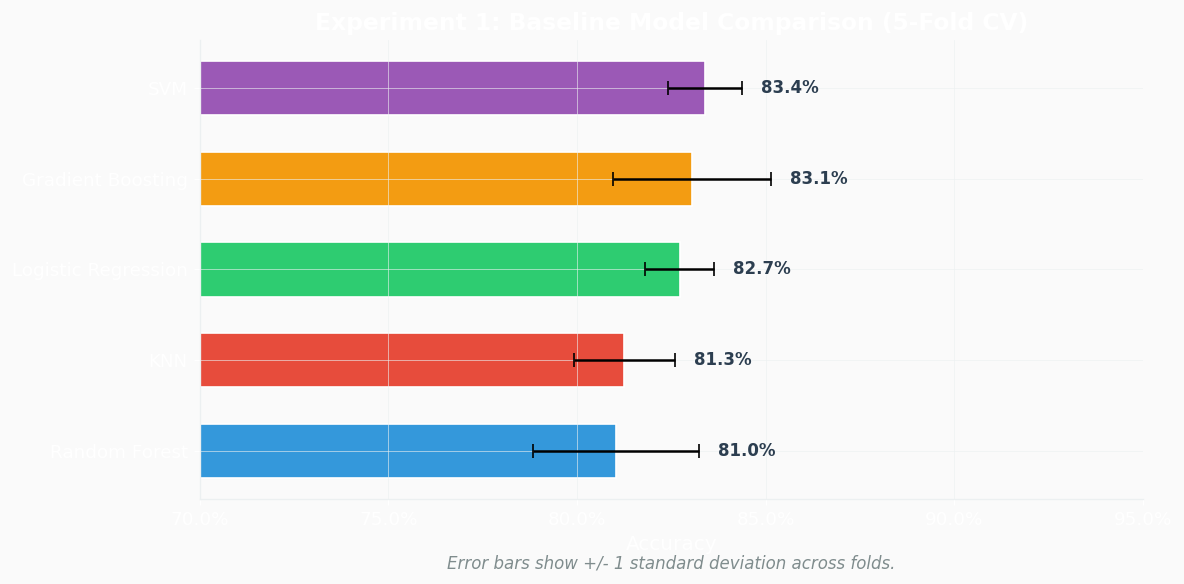

In [77]:
names = list(baseline_results.keys())
means = [baseline_results[n]['mean'] for n in names]
stds = [baseline_results[n]['std'] for n in names]

# Sort by mean accuracy
order = np.argsort(means)
names = [names[i] for i in order]
means = [means[i] for i in order]
stds = [stds[i] for i in order]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(names, means, xerr=stds, color=PALETTE[:len(names)],
               edgecolor='white', height=0.6, capsize=4)
for bar, mean, std in zip(bars, means, stds):
    ax.text(mean + std + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{mean:.1%}', va='center', fontsize=10, fontweight='bold', color=COLORS['primary'])
ax.set_xlim(0.7, 0.95)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_title('Experiment 1: Baseline Model Comparison (5-Fold CV)')
ax.set_xlabel('Accuracy')
add_subtitle(ax, 'Error bars show +/- 1 standard deviation across folds.')
fig.tight_layout()
plt.show()

### Experiment 2 — Hyperparameter Tuning (Top 3 Models)

In [78]:
# ── Search spaces ────────────────────────────────────────────────────────────

tuning_configs = {
    'Random Forest': {
        'classifier': RandomForestClassifier(random_state=SEED),
        'params': {
            'classifier__n_estimators': [100, 200, 300, 500],
            'classifier__max_depth': [None, 5, 10, 15, 20],
            'classifier__min_samples_split': [2, 5, 10],
            'classifier__min_samples_leaf': [1, 2, 4],
            'classifier__max_features': ['sqrt', 'log2'],
        },
    },
    'Gradient Boosting': {
        'classifier': GradientBoostingClassifier(random_state=SEED),
        'params': {
            'classifier__n_estimators': [100, 200, 300, 500],
            'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
            'classifier__max_depth': [3, 5, 7, 10],
            'classifier__subsample': [0.7, 0.8, 0.9, 1.0],
            'classifier__min_samples_leaf': [1, 2, 4],
        },
    },
    'SVM': {
        'classifier': SVC(random_state=SEED, probability=True),
        'params': {
            'classifier__C': [0.1, 0.5, 1.0, 5.0, 10.0],
            'classifier__kernel': ['rbf', 'poly'],
            'classifier__gamma': ['scale', 'auto', 0.01, 0.1],
        },
    },
}

tuned_results = {}

for name, config in tuning_configs.items():
    print(f'\nTuning {name}...')
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('imputer', KNNImputer()),
        ('classifier', config['classifier']),
    ])

    search = RandomizedSearchCV(
        pipe,
        param_distributions=config['params'],
        n_iter=30,
        cv=cv,
        scoring='accuracy',
        random_state=SEED,
        n_jobs=-1,
        verbose=0,
    )
    search.fit(X, y)

    tuned_results[name] = {
        'best_score': search.best_score_,
        'best_params': {k.replace('classifier__', ''): v for k, v in search.best_params_.items()},
        'best_estimator': search.best_estimator_,
    }
    print(f'  Best CV accuracy: {search.best_score_:.4f}')
    print(f'  Best params: {tuned_results[name]["best_params"]}')

print('\nHyperparameter tuning complete.')


Tuning Random Forest...
  Best CV accuracy: 0.8395
  Best params: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 15}

Tuning Gradient Boosting...
  Best CV accuracy: 0.8429
  Best params: {'subsample': 0.8, 'n_estimators': 200, 'min_samples_leaf': 2, 'max_depth': 3, 'learning_rate': 0.05}

Tuning SVM...
  Best CV accuracy: 0.8361
  Best params: {'kernel': 'rbf', 'gamma': 0.01, 'C': 10.0}

Hyperparameter tuning complete.


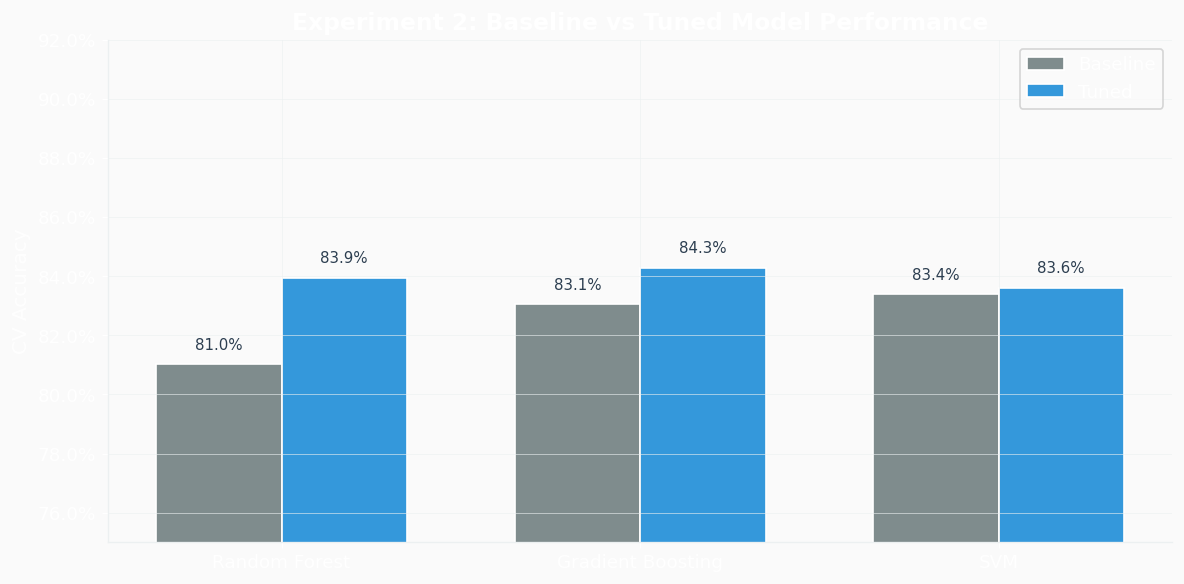

In [79]:
# Compare baseline vs tuned
compare_models = list(tuning_configs.keys())
baseline_scores = [baseline_results[m]['mean'] for m in compare_models]
tuned_scores = [tuned_results[m]['best_score'] for m in compare_models]

x = np.arange(len(compare_models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width / 2, baseline_scores, width, label='Baseline', color=COLORS['secondary'], edgecolor='white')
bars2 = ax.bar(x + width / 2, tuned_scores, width, label='Tuned', color=COLORS['accent'], edgecolor='white')

for bars in [bars1, bars2]:
    bar_with_labels(ax, bars, fmt='{:.1%}', offset=0.005)

ax.set_xticks(x)
ax.set_xticklabels(compare_models)
ax.set_ylim(0.75, 0.92)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_ylabel('CV Accuracy')
ax.set_title('Experiment 2: Baseline vs Tuned Model Performance')
ax.legend()
fig.tight_layout()
plt.show()

### Experiment 3 — Feature Importance

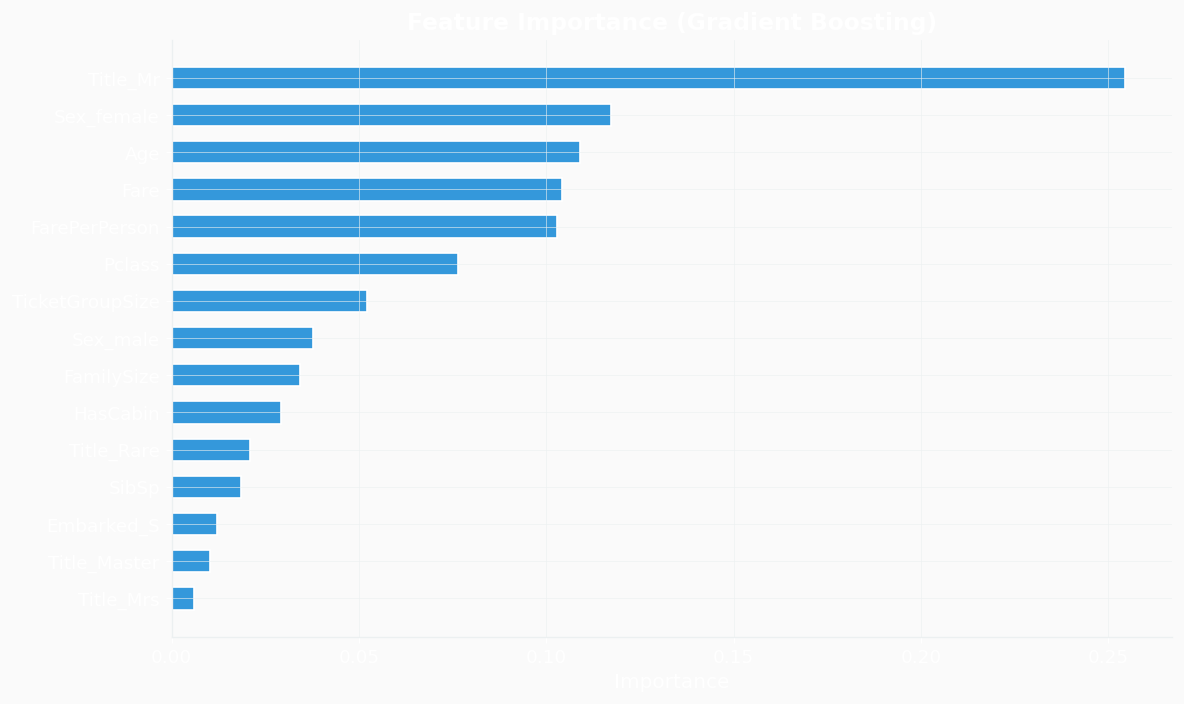

In [80]:
# Use the best tree-based model for feature importance
best_tree_name = max(
    [n for n in tuned_results if n in ('Random Forest', 'Gradient Boosting')],
    key=lambda n: tuned_results[n]['best_score'],
)
best_pipe = tuned_results[best_tree_name]['best_estimator']

# Get feature names from the preprocessor
best_pipe.fit(X, y)
feature_names = best_pipe.named_steps['preprocessor'].get_feature_names_out()
feature_names = [f.split('__')[-1] for f in feature_names]  # clean up prefixes

# Built-in feature importance
clf = best_pipe.named_steps['classifier']
importances = clf.feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=True)
top_n = feat_imp.tail(15)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_n.index, top_n.values, color=COLORS['accent'], edgecolor='white', height=0.6)
ax.set_title(f'Feature Importance ({best_tree_name})')
ax.set_xlabel('Importance')
fig.tight_layout()
plt.show()

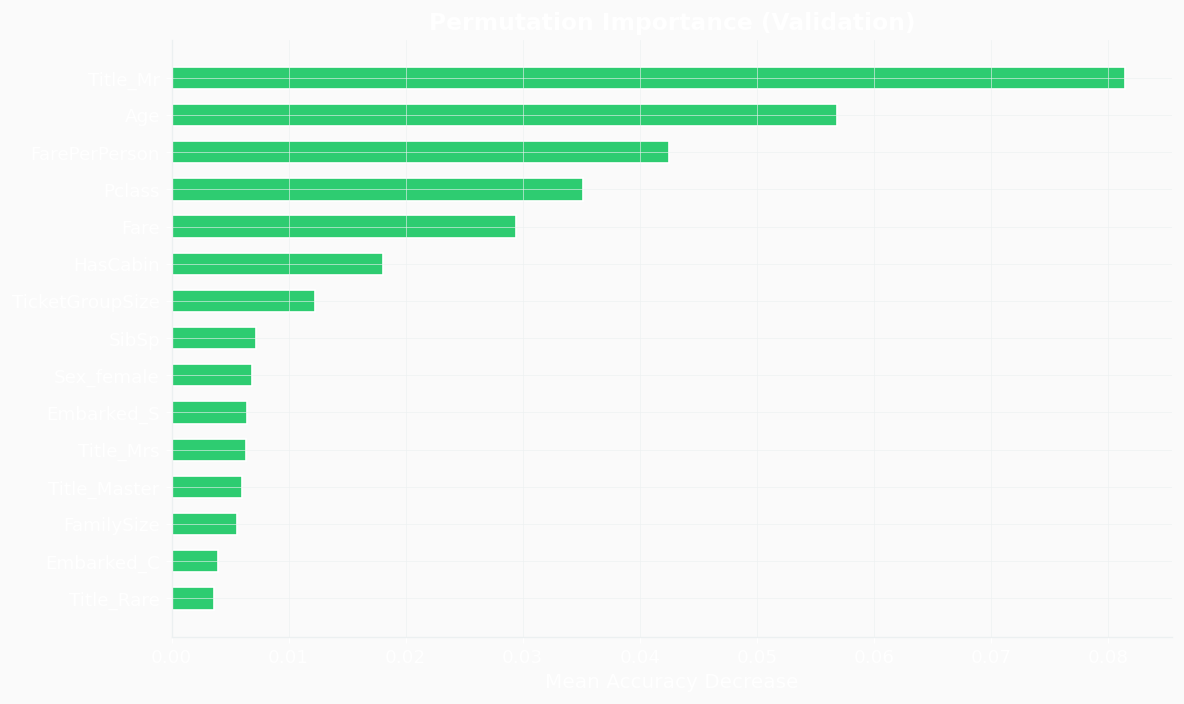

In [81]:
# Permutation importance (model-agnostic validation)
X_transformed = Pipeline(best_pipe.steps[:-1]).transform(X)

perm_imp = permutation_importance(clf, X_transformed, y, n_repeats=20, random_state=SEED, n_jobs=-1)
perm_series = pd.Series(perm_imp.importances_mean, index=feature_names).sort_values(ascending=True)
top_perm = perm_series.tail(15)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_perm.index, top_perm.values, color=PALETTE[2], edgecolor='white', height=0.6)
ax.set_title('Permutation Importance (Validation)')
ax.set_xlabel('Mean Accuracy Decrease')
fig.tight_layout()
plt.show()

### Experiment 4 — PCA Exploration

The original notebook used 3 PCA components capturing only ~30% of variance. Is PCA even helpful here?

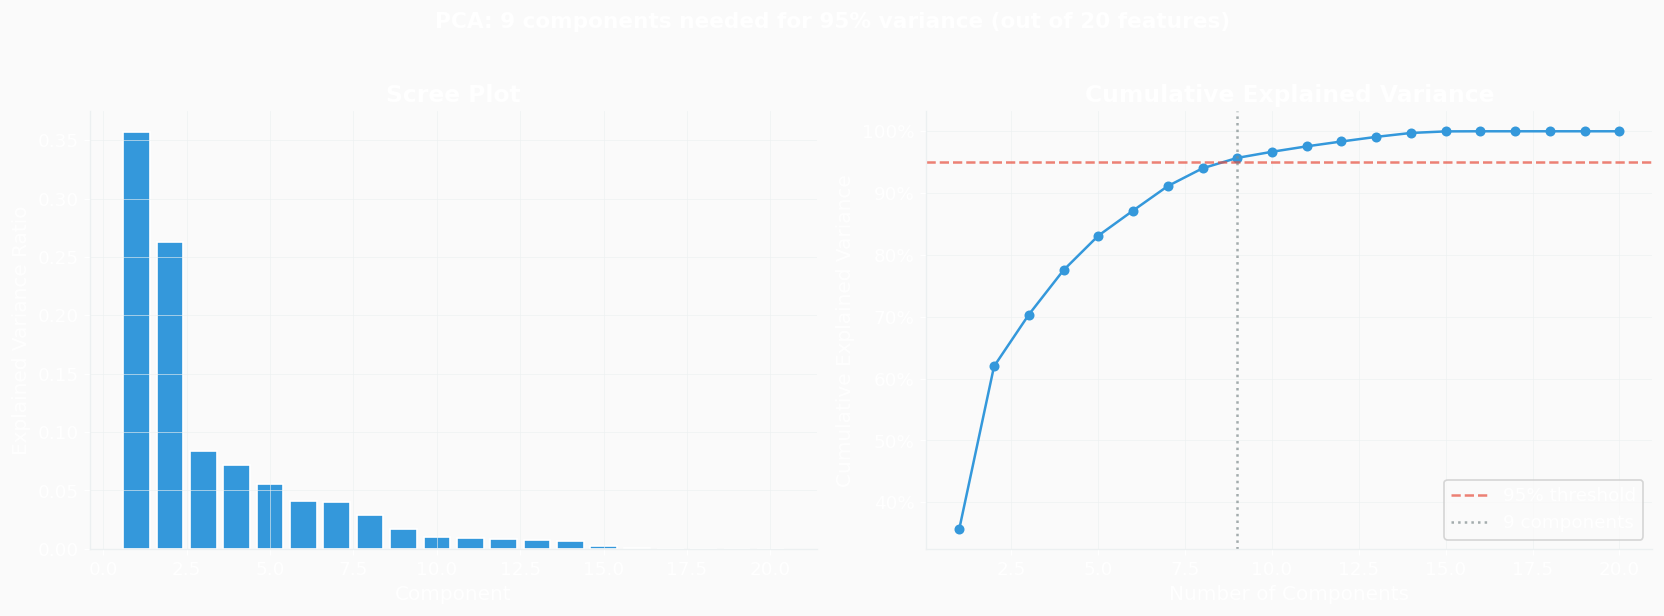

In [82]:
# Transform data through preprocessing + imputer
pre_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('imputer', KNNImputer()),
])
X_pre = pre_pipe.fit_transform(X)

# Full PCA
pca_full = PCA(random_state=SEED).fit(X_pre)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
ax1.bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
        pca_full.explained_variance_ratio_, color=COLORS['accent'], edgecolor='white')
ax1.set_xlabel('Component')
ax1.set_ylabel('Explained Variance Ratio')
ax1.set_title('Scree Plot')

# Cumulative variance
ax2.plot(range(1, len(cumvar) + 1), cumvar, 'o-', color=COLORS['accent'], markersize=5)
ax2.axhline(y=0.95, color=COLORS['perished'], linestyle='--', alpha=0.7, label='95% threshold')
n_95 = np.argmax(cumvar >= 0.95) + 1
ax2.axvline(x=n_95, color=COLORS['secondary'], linestyle=':', alpha=0.7, label=f'{n_95} components')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Explained Variance')
ax2.set_title('Cumulative Explained Variance')
ax2.legend()
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

fig.suptitle(f'PCA: {n_95} components needed for 95% variance (out of {X_pre.shape[1]} features)',
             fontsize=13, fontweight='bold', y=1.02)
fig.tight_layout()
plt.show()

In [83]:
# Compare: best model with vs without PCA
best_name = max(tuned_results, key=lambda n: tuned_results[n]['best_score'])
best_clf_params = tuned_results[best_name]['best_estimator'].named_steps['classifier'].get_params()

# Reconstruct the best classifier with its tuned params
if best_name == 'Random Forest':
    best_clf = RandomForestClassifier(**best_clf_params)
elif best_name == 'Gradient Boosting':
    best_clf = GradientBoostingClassifier(**best_clf_params)
else:
    best_clf = SVC(**best_clf_params)

# Without PCA
pipe_no_pca = Pipeline([
    ('preprocessor', preprocessor),
    ('imputer', KNNImputer()),
    ('classifier', best_clf),
])
scores_no_pca = cross_val_score(pipe_no_pca, X, y, cv=cv, scoring='accuracy')

# With PCA (95% variance)
if best_name == 'Random Forest':
    pca_clf = RandomForestClassifier(**best_clf_params)
elif best_name == 'Gradient Boosting':
    pca_clf = GradientBoostingClassifier(**best_clf_params)
else:
    pca_clf = SVC(**best_clf_params)

pipe_with_pca = Pipeline([
    ('preprocessor', preprocessor),
    ('imputer', KNNImputer()),
    ('pca', PCA(n_components=0.95, random_state=SEED)),
    ('classifier', pca_clf),
])
scores_with_pca = cross_val_score(pipe_with_pca, X, y, cv=cv, scoring='accuracy')

print(f'{best_name} WITHOUT PCA: {scores_no_pca.mean():.4f} +/- {scores_no_pca.std():.4f}')
print(f'{best_name} WITH PCA (95%): {scores_with_pca.mean():.4f} +/- {scores_with_pca.std():.4f}')
print(f'\nVerdict: PCA {"helps" if scores_with_pca.mean() > scores_no_pca.mean() else "does not help"} for this model.')

Gradient Boosting WITHOUT PCA: 0.8406 +/- 0.0173
Gradient Boosting WITH PCA (95%): 0.8260 +/- 0.0131

Verdict: PCA does not help for this model.


### Experiment Summary

In [84]:
summary_rows = []
for name in models:
    row = {'Model': name, 'Baseline CV': f'{baseline_results[name]["mean"]:.4f}'}
    if name in tuned_results:
        row['Tuned CV'] = f'{tuned_results[name]["best_score"]:.4f}'
        row['Best Params'] = str(tuned_results[name]['best_params'])
    else:
        row['Tuned CV'] = '-'
        row['Best Params'] = '-'
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index('Model')
summary_df

,Baseline CV,Tuned CV,Best Params
Model,,,
Logistic Regression,0.8272,-,-
Random Forest,0.8103,0.8395,"{'n_estimators': 300, 'min_samples_split': 5, ..."
Gradient Boosting,0.8305,0.8429,"{'subsample': 0.8, 'n_estimators': 200, 'min_s..."
SVM,0.8339,0.8361,"{'kernel': 'rbf', 'gamma': 0.01, 'C': 10.0}"
KNN,0.8126,-,-


---

## 7. Final Evaluation

Let's take the best overall model and evaluate it in detail.

In [85]:
# Identify the best model
best_overall = max(tuned_results, key=lambda n: tuned_results[n]['best_score'])
best_estimator = tuned_results[best_overall]['best_estimator']
print(f'Best model: {best_overall} (CV accuracy: {tuned_results[best_overall]["best_score"]:.4f})')

# Fit on full training data
best_estimator.fit(X, y)
y_pred = best_estimator.predict(X)

print(f'\nClassification Report (on training data):\n')
print(classification_report(y, y_pred, target_names=['Perished', 'Survived']))

Best model: Gradient Boosting (CV accuracy: 0.8429)

Classification Report (on training data):

              precision    recall  f1-score   support

    Perished       0.91      0.96      0.93       549
    Survived       0.92      0.85      0.88       342

    accuracy                           0.91       891
   macro avg       0.92      0.90      0.91       891
weighted avg       0.92      0.91      0.91       891



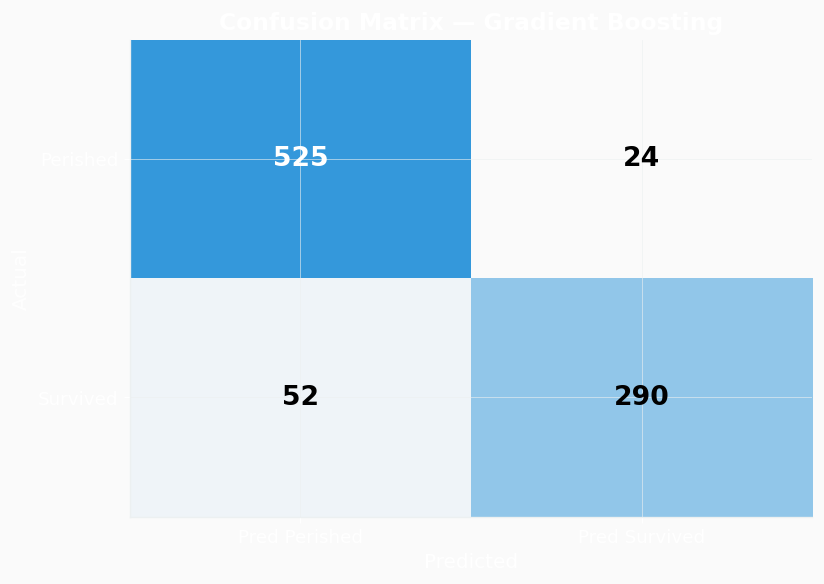

In [86]:
cm = confusion_matrix(y, y_pred)
cm_df = pd.DataFrame(cm, index=['Perished', 'Survived'], columns=['Pred Perished', 'Pred Survived'])

fig, ax = plt.subplots(figsize=(7, 5))
cmap = LinearSegmentedColormap.from_list('blues', ['#fafafa', COLORS['accent']])
im = ax.imshow(cm, cmap=cmap, aspect='auto')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Pred Perished', 'Pred Survived'])
ax.set_yticks([0, 1])
ax.set_yticklabels(['Perished', 'Survived'])
for i in range(2):
    for j in range(2):
        color = 'white' if cm[i, j] > cm.max() * 0.6 else 'black'
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=16, fontweight='bold', color=color)
ax.set_title(f'Confusion Matrix — {best_overall}')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
fig.tight_layout()
plt.show()

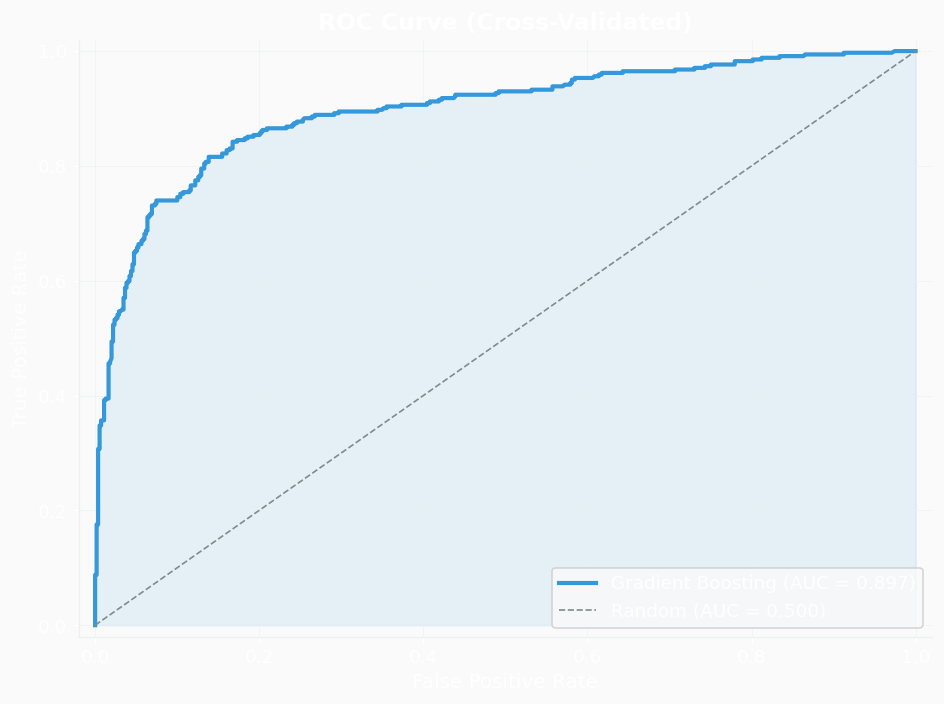

In [87]:
# ROC Curve (using cross-validated predictions for a fairer estimate)
from sklearn.model_selection import cross_val_predict

# Re-fit best pipeline with probability support
if hasattr(best_estimator.named_steps['classifier'], 'predict_proba'):
    y_proba = cross_val_predict(best_estimator, X, y, cv=cv, method='predict_proba')[:, 1]
else:
    y_proba = cross_val_predict(best_estimator, X, y, cv=cv, method='decision_function')

fpr, tpr, _ = roc_curve(y, y_proba)
auc = roc_auc_score(y, y_proba)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color=COLORS['accent'], lw=2.5, label=f'{best_overall} (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], color=COLORS['secondary'], lw=1, linestyle='--', label='Random (AUC = 0.500)')
ax.fill_between(fpr, tpr, alpha=0.1, color=COLORS['accent'])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve (Cross-Validated)')
ax.legend(loc='lower right', fontsize=11)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
fig.tight_layout()
plt.show()

---

## 8. Conclusion — What the Data Says

After exploring the Titanic passenger data, the story is clear:

1. **Sex was the strongest predictor.** Women survived at nearly 4x the rate of men. The "women and children first" protocol was real and powerful.

2. **Class was the silent filter.** While the protocol favoured women, it did so *unequally*. Nearly all 1st and 2nd class women survived, but only about half of 3rd class women did. Class determined who even reached the lifeboats.

3. **Children were partially protected.** All children in 1st and 2nd class survived. But 3rd class children had roughly the same odds as 3rd class adults — the protocol broke down where it mattered most.

4. **Family size mattered.** Solo travellers and very large families had the worst outcomes. Mid-sized families (2-4) had the best survival rates — perhaps because they had someone to help them but weren't slowed by a large group.

5. **Feature engineering matters.** Title, family size, and fare-per-person all proved informative. The raw ticket price was misleading because it was often shared across a group.

The answer to our opening question? **Both chivalry and privilege — but when they conflicted, privilege won.**